# Comprehensive Overfitting Investigation: All PPO Models

This notebook provides detailed overfitting analysis for all PPO models (3 reward types):

**Models Analyzed:**
1. PPO with `log_return` reward
2. PPO with `multi_component` reward
3. PPO with `risk_aware` reward

**Analysis Components:**

**Part 1:** Individual Model Analysis
- Learning curves (train vs validation Sharpe)
- Peak detection and early stopping analysis
- Train-validation performance gaps
- Overfitting risk assessment per model

**Part 2:** Multi-Model Comparison
- Cross-model overfitting metrics comparison
- Which reward type overfits least?
- Validation-test gap comparison
- Overall overfitting ranking

**Part 3:** Recommendations
- Best reward type for generalization
- Suggested improvements per model
- Production model selection

**Uses well-structured viz functions** from `viz.py` module.

## Setup & Imports

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Setup
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Import viz functions
from viz import (
    # Individual model analysis
    plot_learning_curves,
    analyze_peak_positions,
    plot_train_val_comparison,
    plot_validation_test_gap,
    # Multi-model comparison
    plot_multi_model_learning_curves,
    compare_overfitting_metrics,
    plot_multi_model_val_test_gap,
    create_overfitting_summary_table
)

# Paths
DATA_DIR = project_root / 'data' / 'processed'
MODELS_DIR = project_root / 'models'
RESULTS_DIR = project_root / 'results' / 'backtests'
OUTPUT_DIR = project_root / 'results' / 'overfitting_analysis'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Model names
PPO_REWARD_TYPES = ['log_return', 'multi_component', 'risk_aware']
N_FOLDS = 3

print(f"✓ Setup complete")
print(f"✓ Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"✓ Output directory: {OUTPUT_DIR}")

✓ Setup complete
✓ Timestamp: 2025-11-18 18:58:05
✓ Output directory: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/overfitting_analysis


## Load Training Logs for All Models

In [2]:
def load_model_logs(reward_type: str):
    """
    Load training and validation logs for a specific PPO model.
    
    Parameters:
    -----------
    reward_type : str
        Reward type ('log_return', 'multi_component', 'risk_aware')
        
    Returns:
    --------
    tuple : (train_logs, val_logs) dictionaries mapping fold_idx to DataFrames
    """
    model_dir = MODELS_DIR / f"ppo_{reward_type}"
    
    train_logs = {}
    val_logs = {}
    
    for fold_idx in range(N_FOLDS):
        fold_dir = model_dir / f'fold_{fold_idx}' / 'logs'
        
        train_path = fold_dir / 'train_episodes.csv'
        val_path = fold_dir / 'val_evaluations.csv'
        
        if train_path.exists():
            train_logs[fold_idx] = pd.read_csv(train_path)
        
        if val_path.exists():
            val_logs[fold_idx] = pd.read_csv(val_path)
    
    return train_logs, val_logs

# Load logs for all models
print("Loading training logs for all PPO models...\n")

all_models_data = {}

for reward_type in PPO_REWARD_TYPES:
    print(f"Loading {reward_type}...")
    train_logs, val_logs = load_model_logs(reward_type)
    
    all_models_data[reward_type] = {
        'train': train_logs,
        'val': val_logs
    }
    
    print(f"  ✓ Train folds: {len(train_logs)}")
    print(f"  ✓ Val folds: {len(val_logs)}")

print(f"\n✓ Loaded logs for {len(all_models_data)} models")

Loading training logs for all PPO models...

Loading log_return...
  ✓ Train folds: 3
  ✓ Val folds: 3
Loading multi_component...
  ✓ Train folds: 3
  ✓ Val folds: 3
Loading risk_aware...
  ✓ Train folds: 3
  ✓ Val folds: 3

✓ Loaded logs for 3 models


---
## Part 1: Individual Model Analysis

Analyze each PPO model separately using the well-structured viz functions.

### 1.1 PPO Log Return Reward

PPO - LOG_RETURN REWARD


1. Learning Curves Analysis:


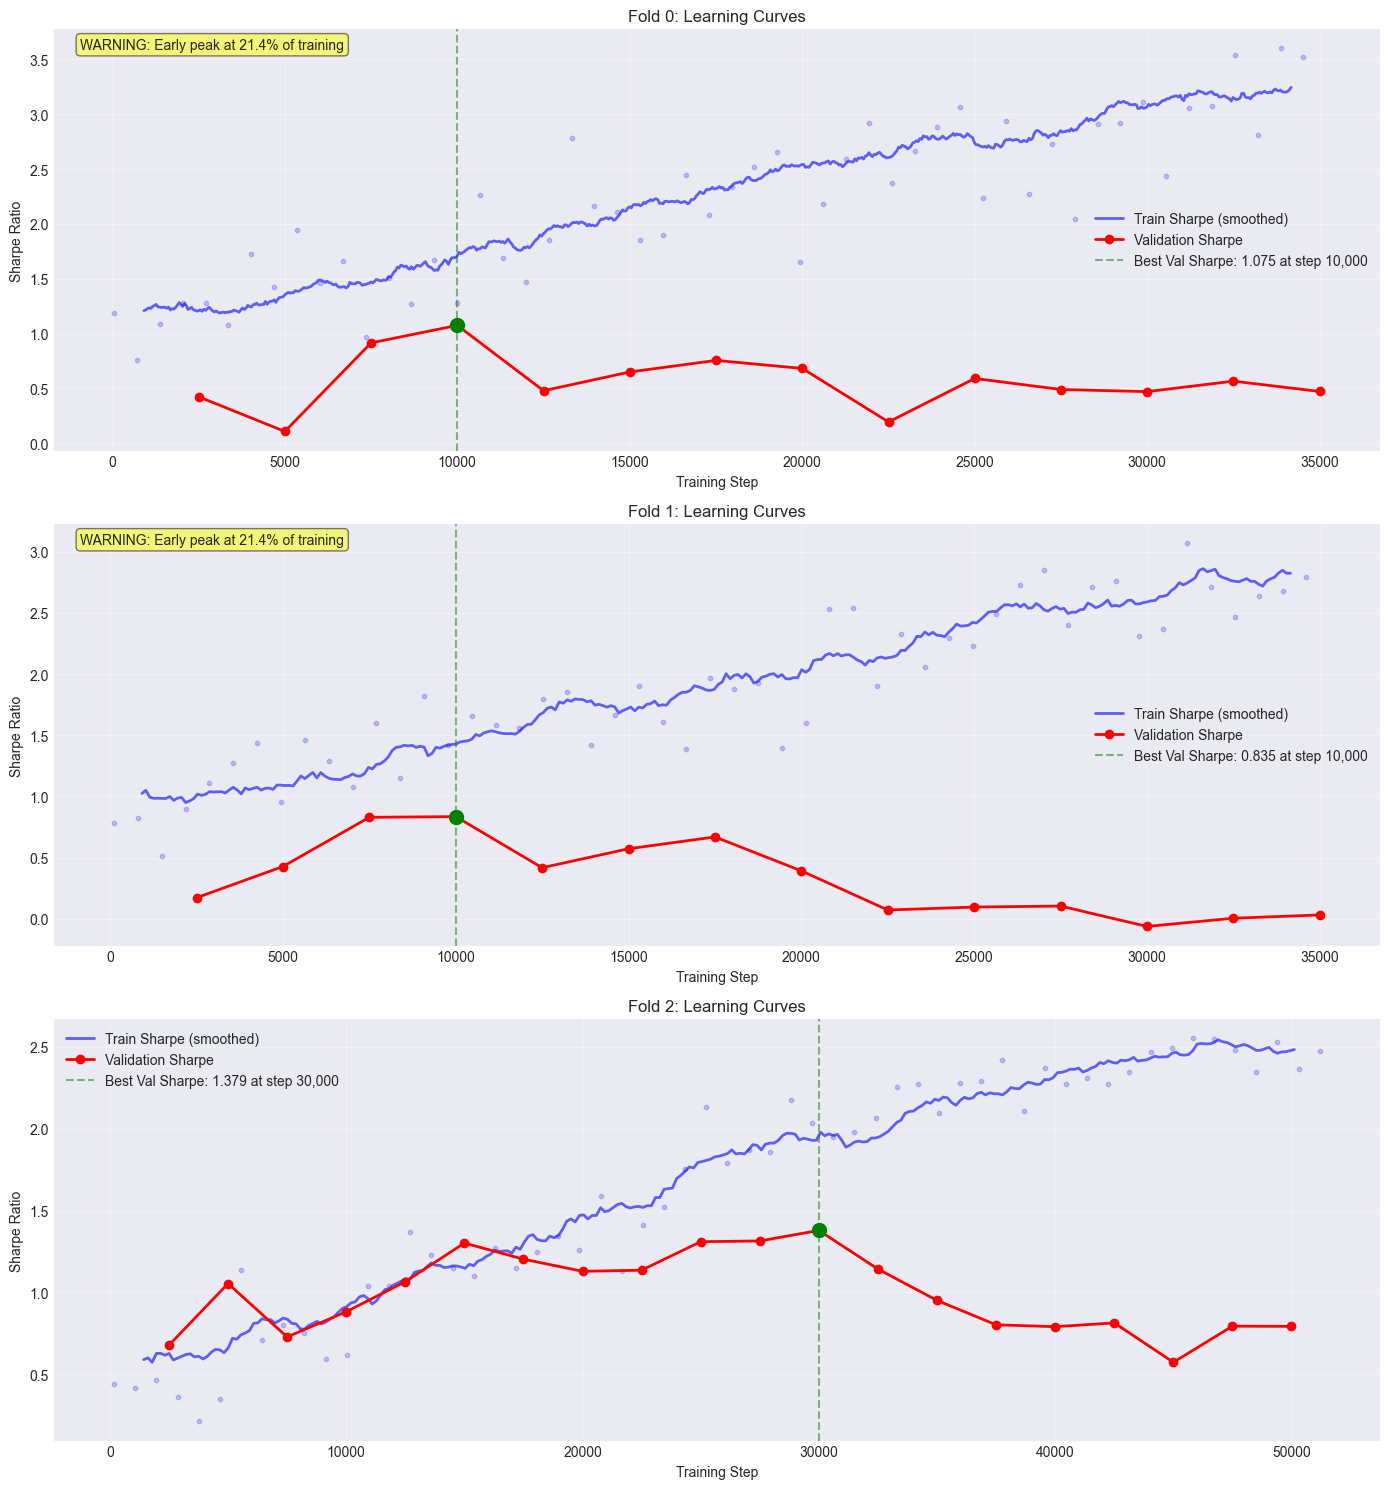

Learning curves saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/overfitting_analysis/ppo_log_return/learning_curves.png

2. Peak Position Analysis:
Validation Sharpe Peak Analysis:

Fold 0.0:
  Peak Sharpe: 1.075 at step 10,000.0
  Final Sharpe: 0.472
  Peak position: 21.4% of training
  Decline from peak: 0.603 (56.1%)

Fold 1.0:
  Peak Sharpe: 0.835 at step 10,000.0
  Final Sharpe: 0.031
  Peak position: 21.4% of training
  Decline from peak: 0.804 (96.2%)

Fold 2.0:
  Peak Sharpe: 1.379 at step 30,000.0
  Final Sharpe: 0.792
  Peak position: 55.0% of training
  Decline from peak: 0.586 (42.5%)


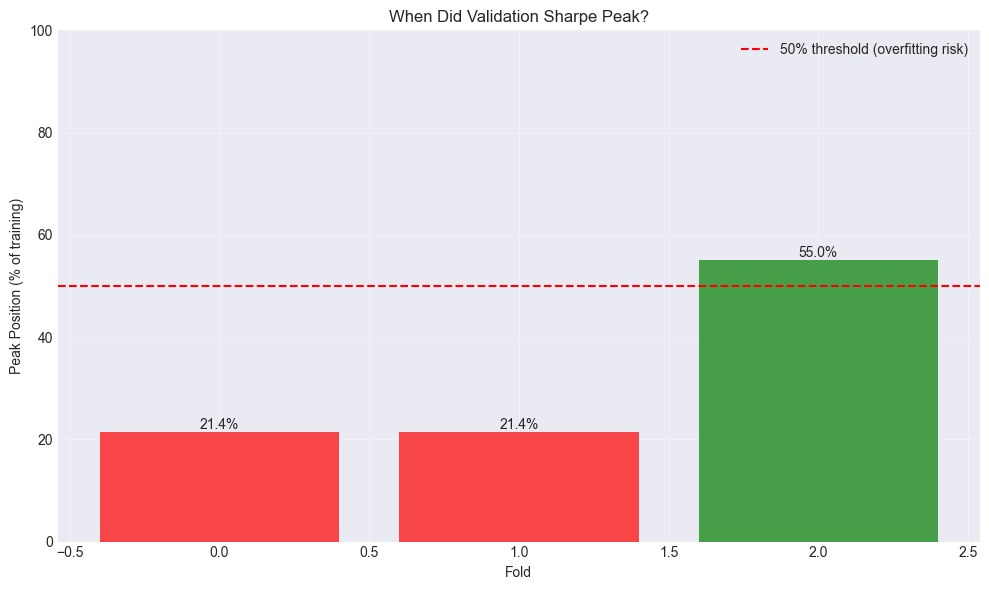


Peak analysis plot saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/overfitting_analysis/ppo_log_return/peak_analysis.png

3. Train vs Validation Comparison:


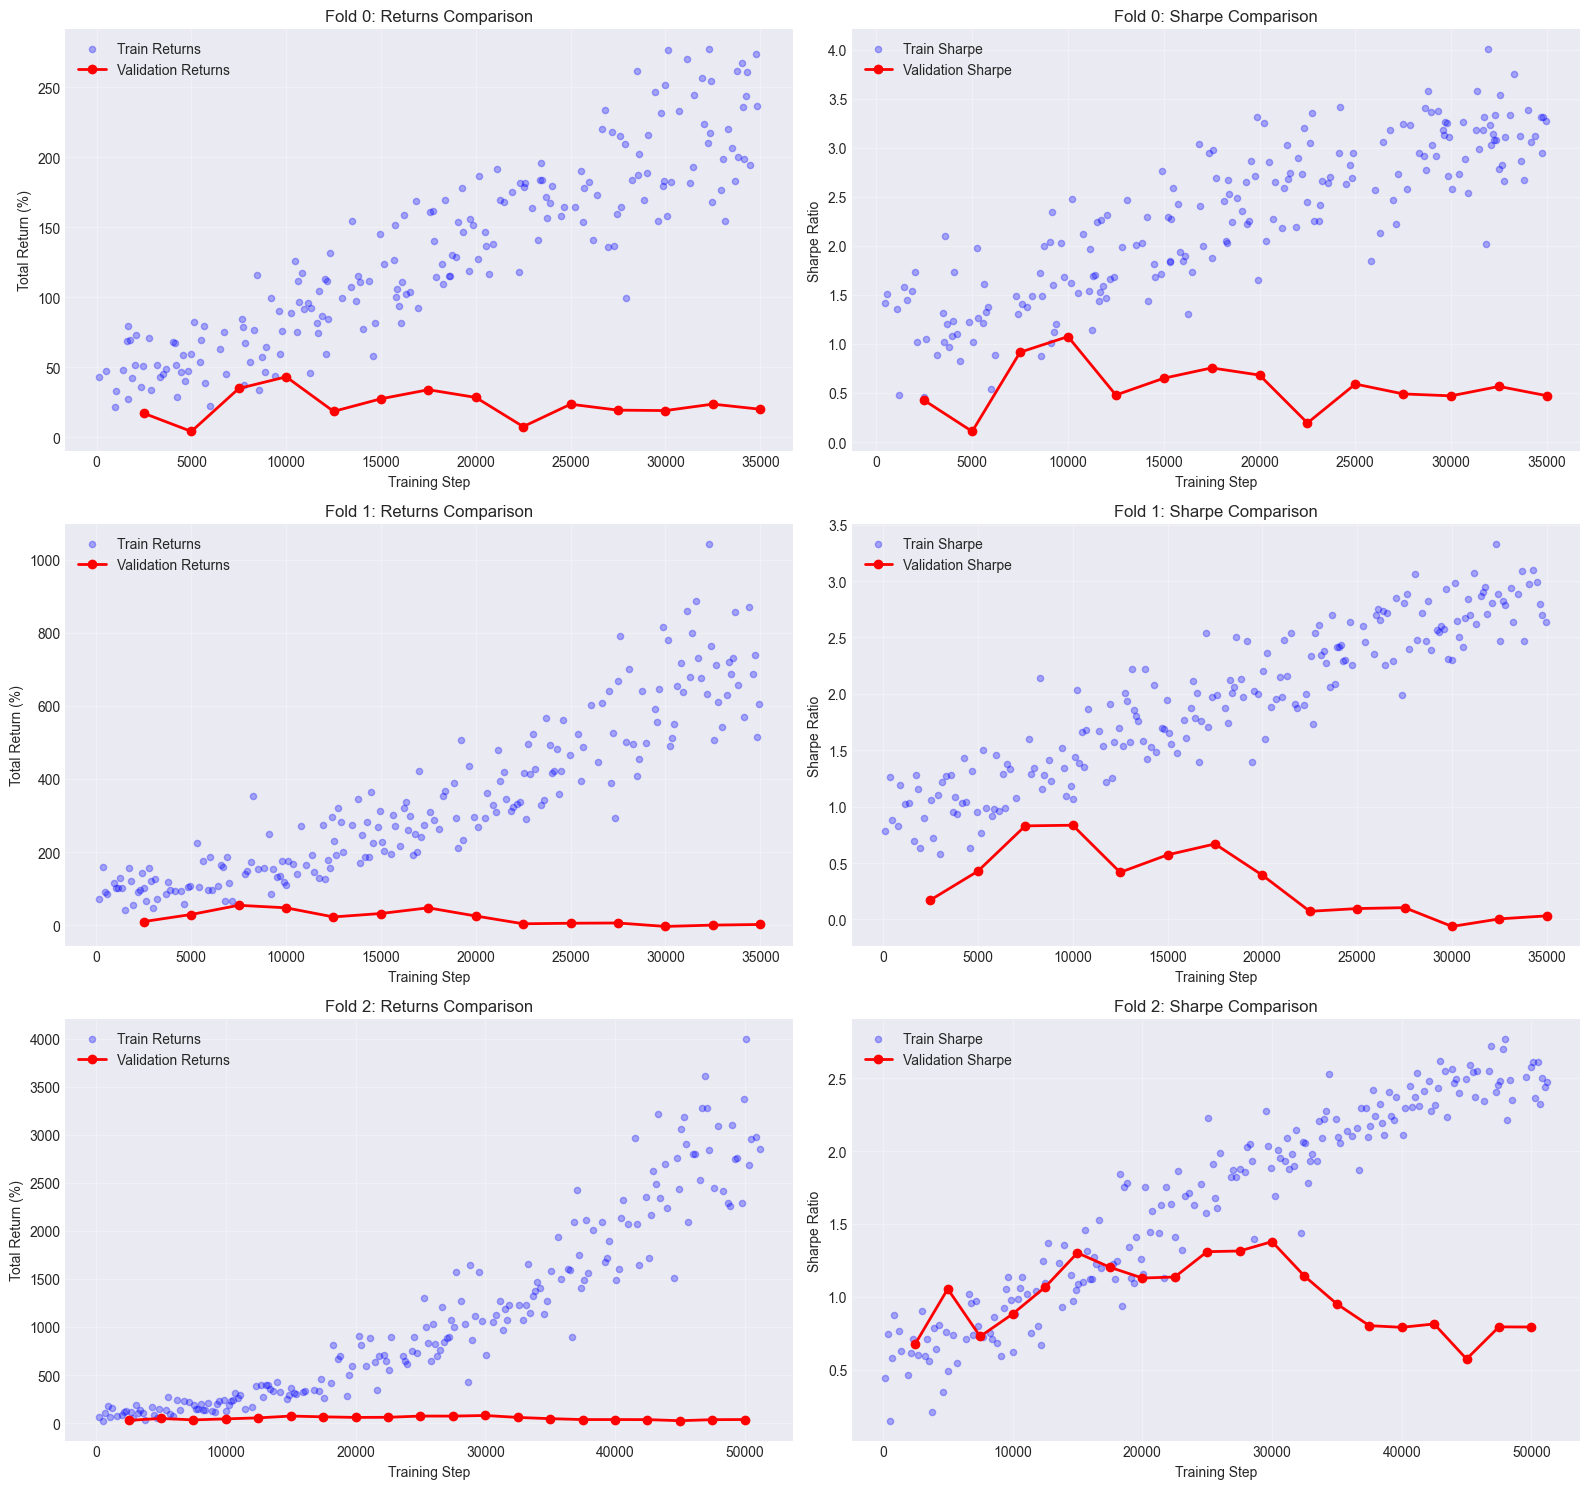


Train vs Validation Returns Summary:

Fold 0:
  Train Return: 128.19% ± 62.48%
  Val Return:   22.93% ± 10.39%
  Gap: 105.26%

Fold 1:
  Train Return: 342.18% ± 213.27%
  Val Return:   20.18% ± 19.61%
  Gap: 322.00%

Fold 2:
  Train Return: 1109.21% ± 957.23%
  Val Return:   50.02% ± 16.71%
  Gap: 1059.19%

Train vs validation comparison plot saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/overfitting_analysis/ppo_log_return/train_val_comparison.png

✓ Individual analysis complete for log_return
✓ Results saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/overfitting_analysis/ppo_log_return


In [3]:
reward_type = 'log_return'
model_data = all_models_data[reward_type]

print(f"{'='*80}")
print(f"PPO - {reward_type.upper()} REWARD")
print(f"{'='*80}\n")

# Create model-specific output directory
model_output_dir = OUTPUT_DIR / f"ppo_{reward_type}"
model_output_dir.mkdir(parents=True, exist_ok=True)

# Plot learning curves
print("\n1. Learning Curves Analysis:")
plot_learning_curves(model_data['train'], model_data['val'], model_output_dir)

# Analyze peak positions
print("\n2. Peak Position Analysis:")
peak_df_log = analyze_peak_positions(model_data['val'], model_output_dir)

# Train vs validation comparison
print("\n3. Train vs Validation Comparison:")
plot_train_val_comparison(model_data['train'], model_data['val'], model_output_dir)

print(f"\n✓ Individual analysis complete for {reward_type}")
print(f"✓ Results saved to: {model_output_dir}")

### 1.2 PPO Multi-Component Reward

PPO - MULTI_COMPONENT REWARD


1. Learning Curves Analysis:


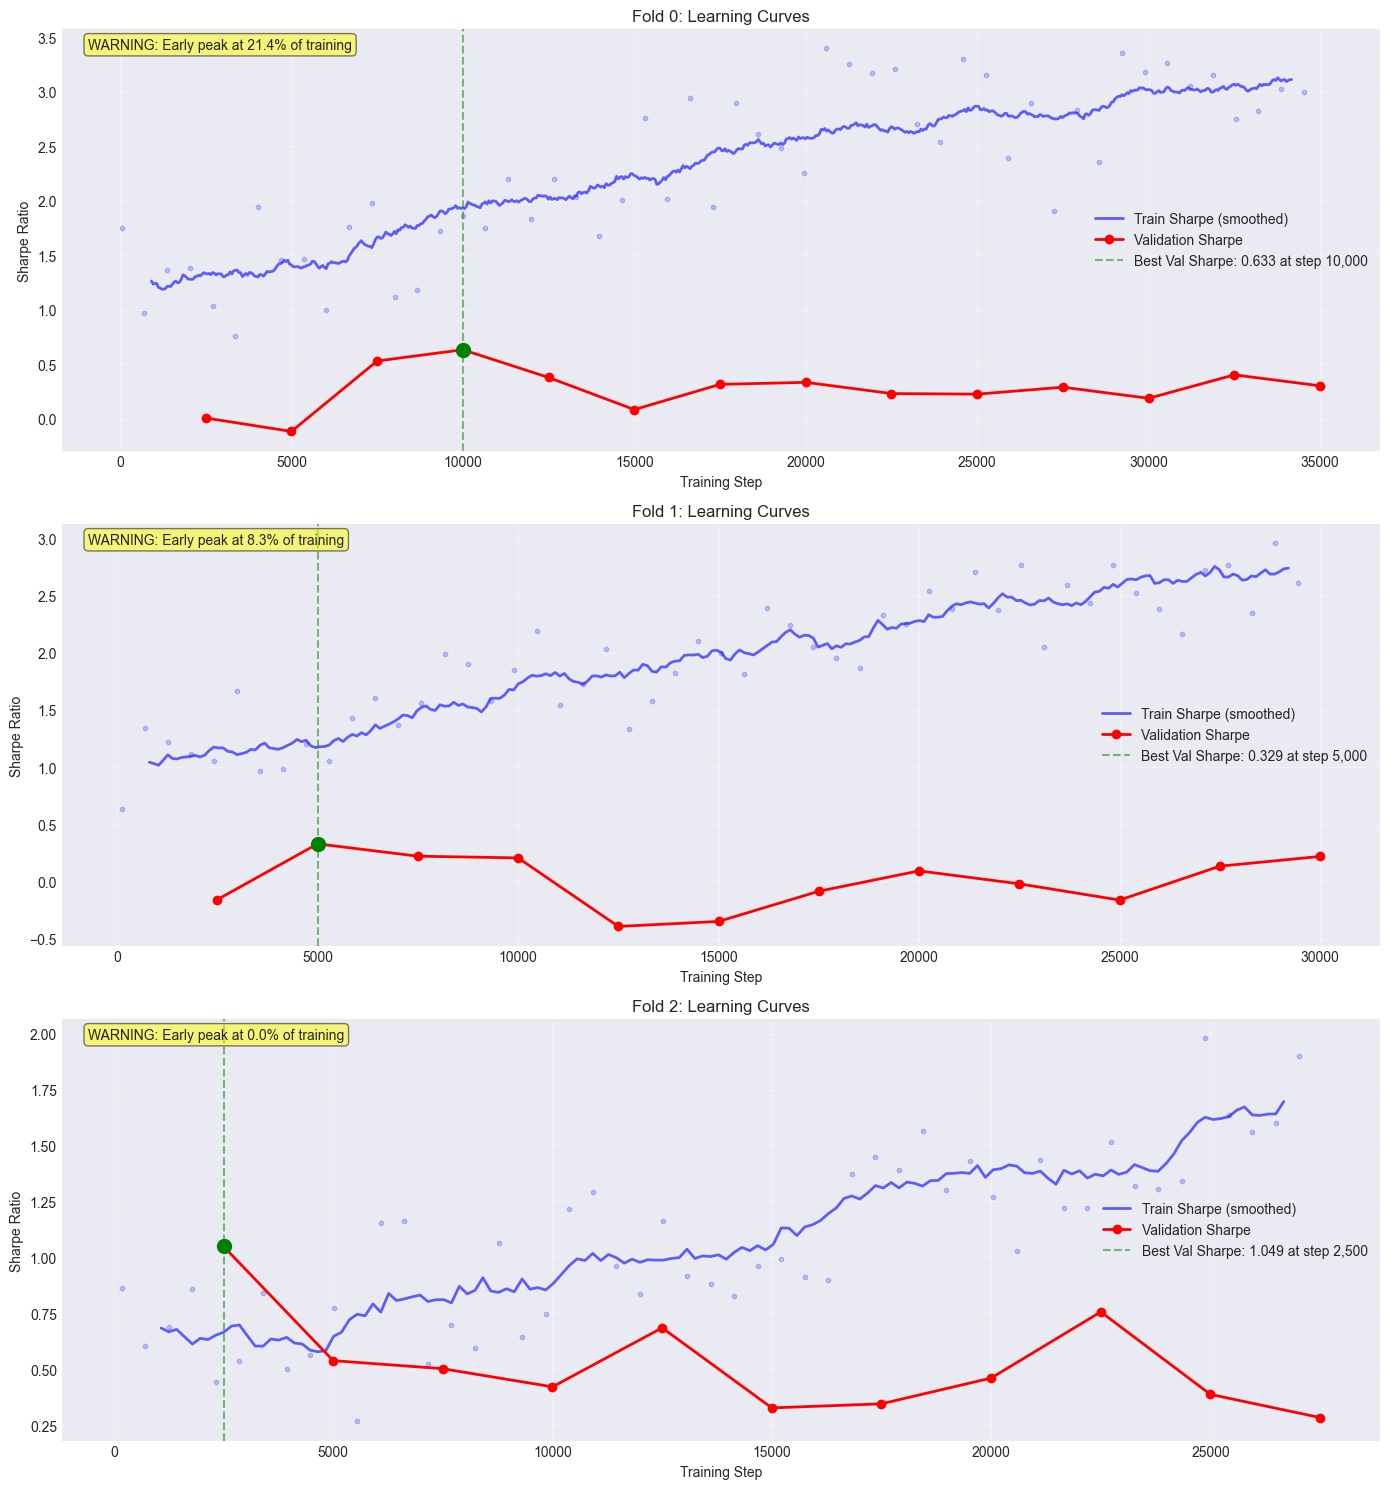

Learning curves saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/overfitting_analysis/ppo_multi_component/learning_curves.png

2. Peak Position Analysis:
Validation Sharpe Peak Analysis:

Fold 0.0:
  Peak Sharpe: 0.633 at step 10,000.0
  Final Sharpe: 0.302
  Peak position: 21.4% of training
  Decline from peak: 0.331 (52.3%)

Fold 1.0:
  Peak Sharpe: 0.329 at step 5,000.0
  Final Sharpe: 0.219
  Peak position: 8.3% of training
  Decline from peak: 0.110 (33.6%)

Fold 2.0:
  Peak Sharpe: 1.049 at step 2,500.0
  Final Sharpe: 0.284
  Peak position: 0.0% of training
  Decline from peak: 0.765 (72.9%)


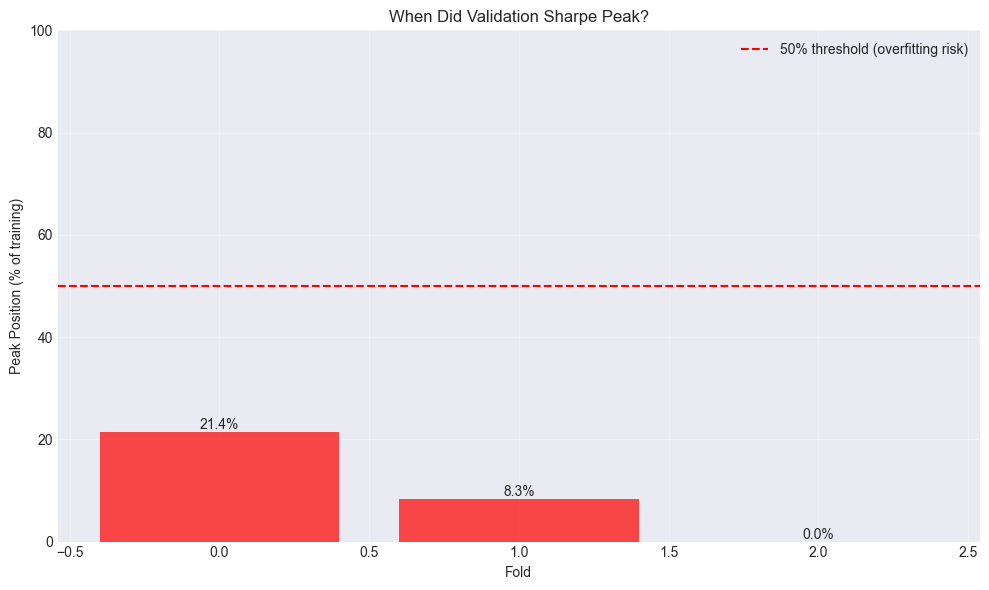


Peak analysis plot saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/overfitting_analysis/ppo_multi_component/peak_analysis.png

3. Train vs Validation Comparison:


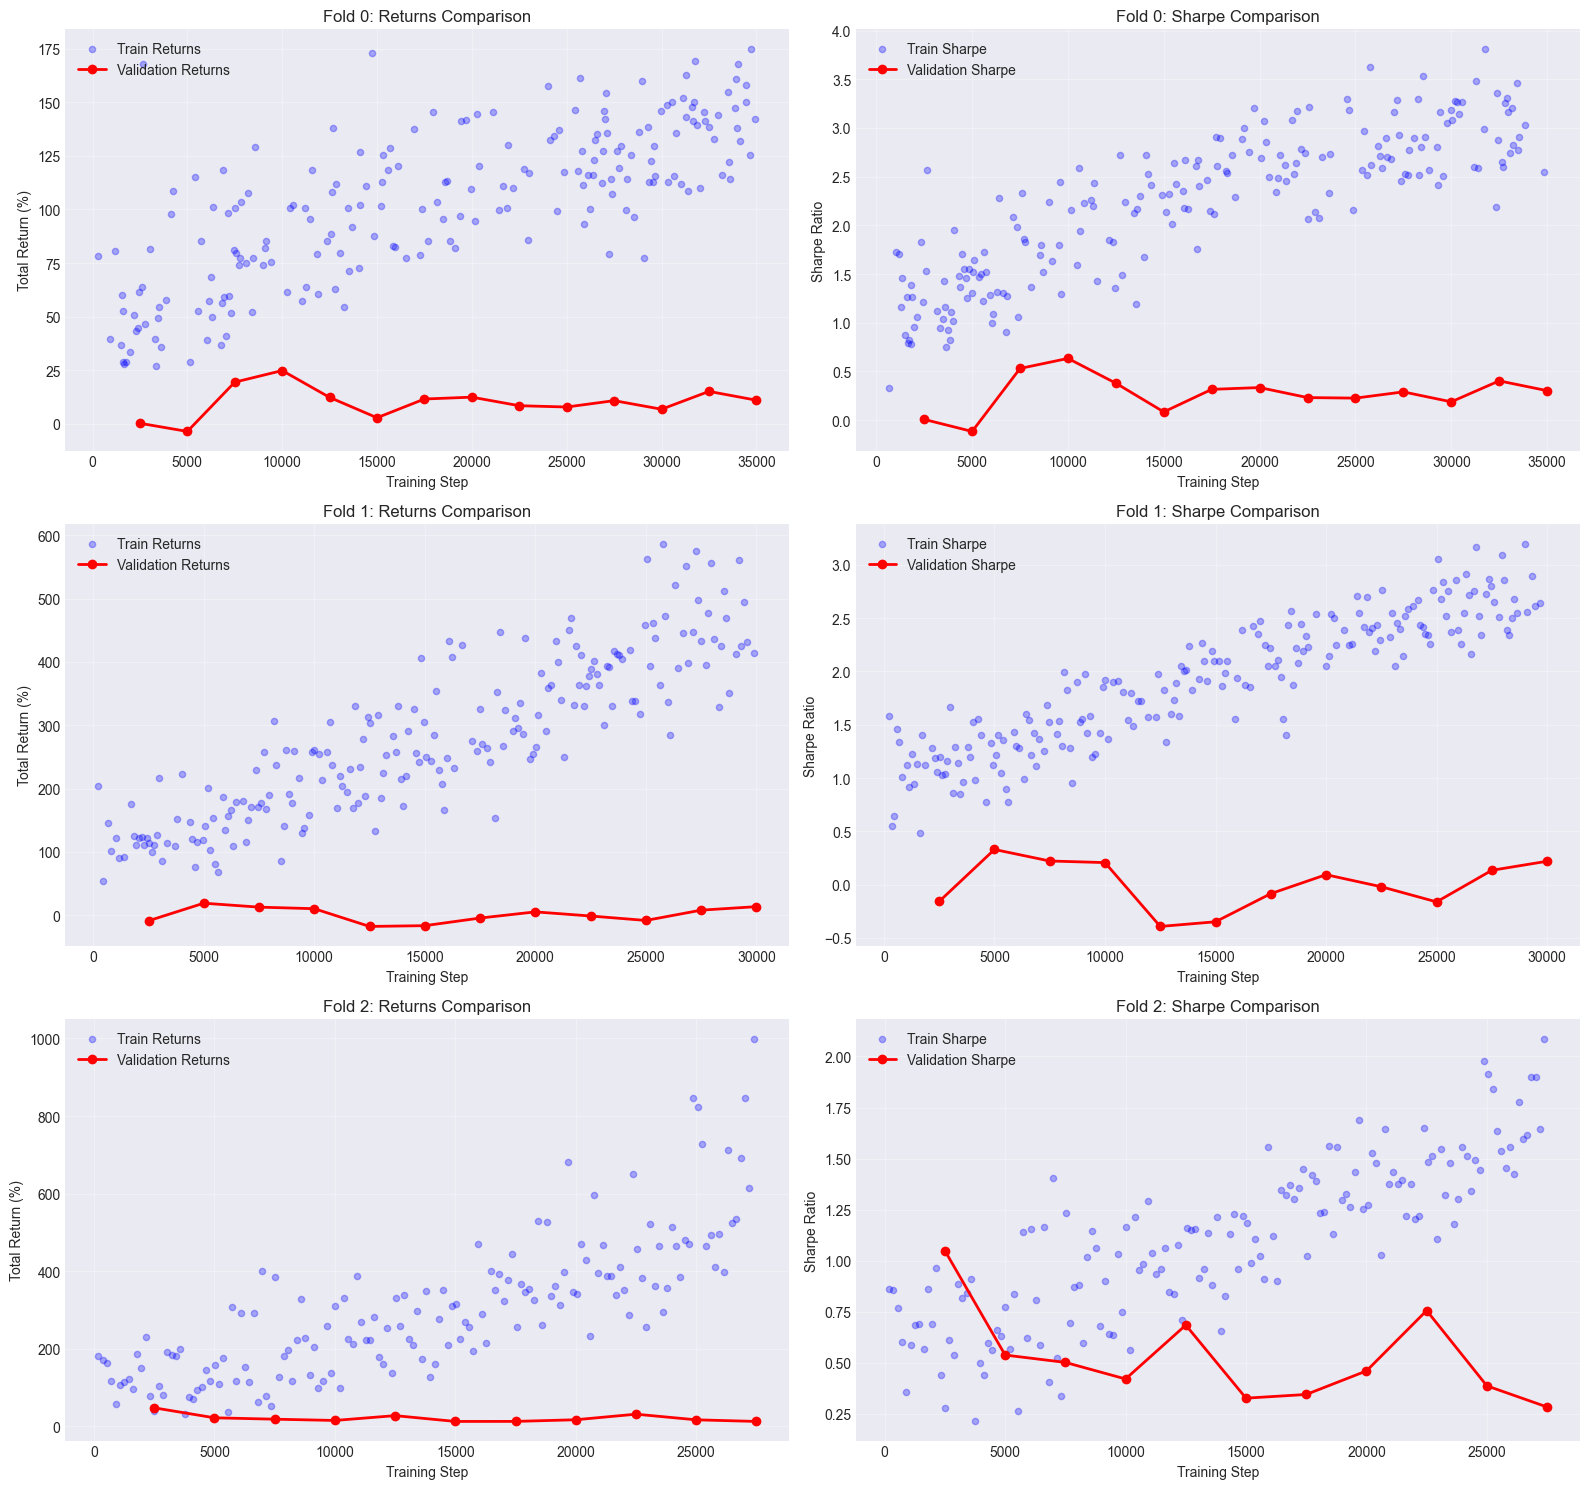


Train vs Validation Returns Summary:

Fold 0:
  Train Return: 103.31% ± 35.61%
  Val Return:   9.99% ± 7.33%
  Gap: 93.33%

Fold 1:
  Train Return: 277.37% ± 126.28%
  Val Return:   1.08% ± 12.23%
  Gap: 276.29%

Fold 2:
  Train Return: 300.52% ± 180.65%
  Val Return:   20.57% ± 10.72%
  Gap: 279.95%

Train vs validation comparison plot saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/overfitting_analysis/ppo_multi_component/train_val_comparison.png

✓ Individual analysis complete for multi_component
✓ Results saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/overfitting_analysis/ppo_multi_component


In [4]:
reward_type = 'multi_component'
model_data = all_models_data[reward_type]

print(f"{'='*80}")
print(f"PPO - {reward_type.upper()} REWARD")
print(f"{'='*80}\n")

model_output_dir = OUTPUT_DIR / f"ppo_{reward_type}"
model_output_dir.mkdir(parents=True, exist_ok=True)

print("\n1. Learning Curves Analysis:")
plot_learning_curves(model_data['train'], model_data['val'], model_output_dir)

print("\n2. Peak Position Analysis:")
peak_df_multi = analyze_peak_positions(model_data['val'], model_output_dir)

print("\n3. Train vs Validation Comparison:")
plot_train_val_comparison(model_data['train'], model_data['val'], model_output_dir)

print(f"\n✓ Individual analysis complete for {reward_type}")
print(f"✓ Results saved to: {model_output_dir}")

### 1.3 PPO Risk-Aware Reward

PPO - RISK_AWARE REWARD


1. Learning Curves Analysis:


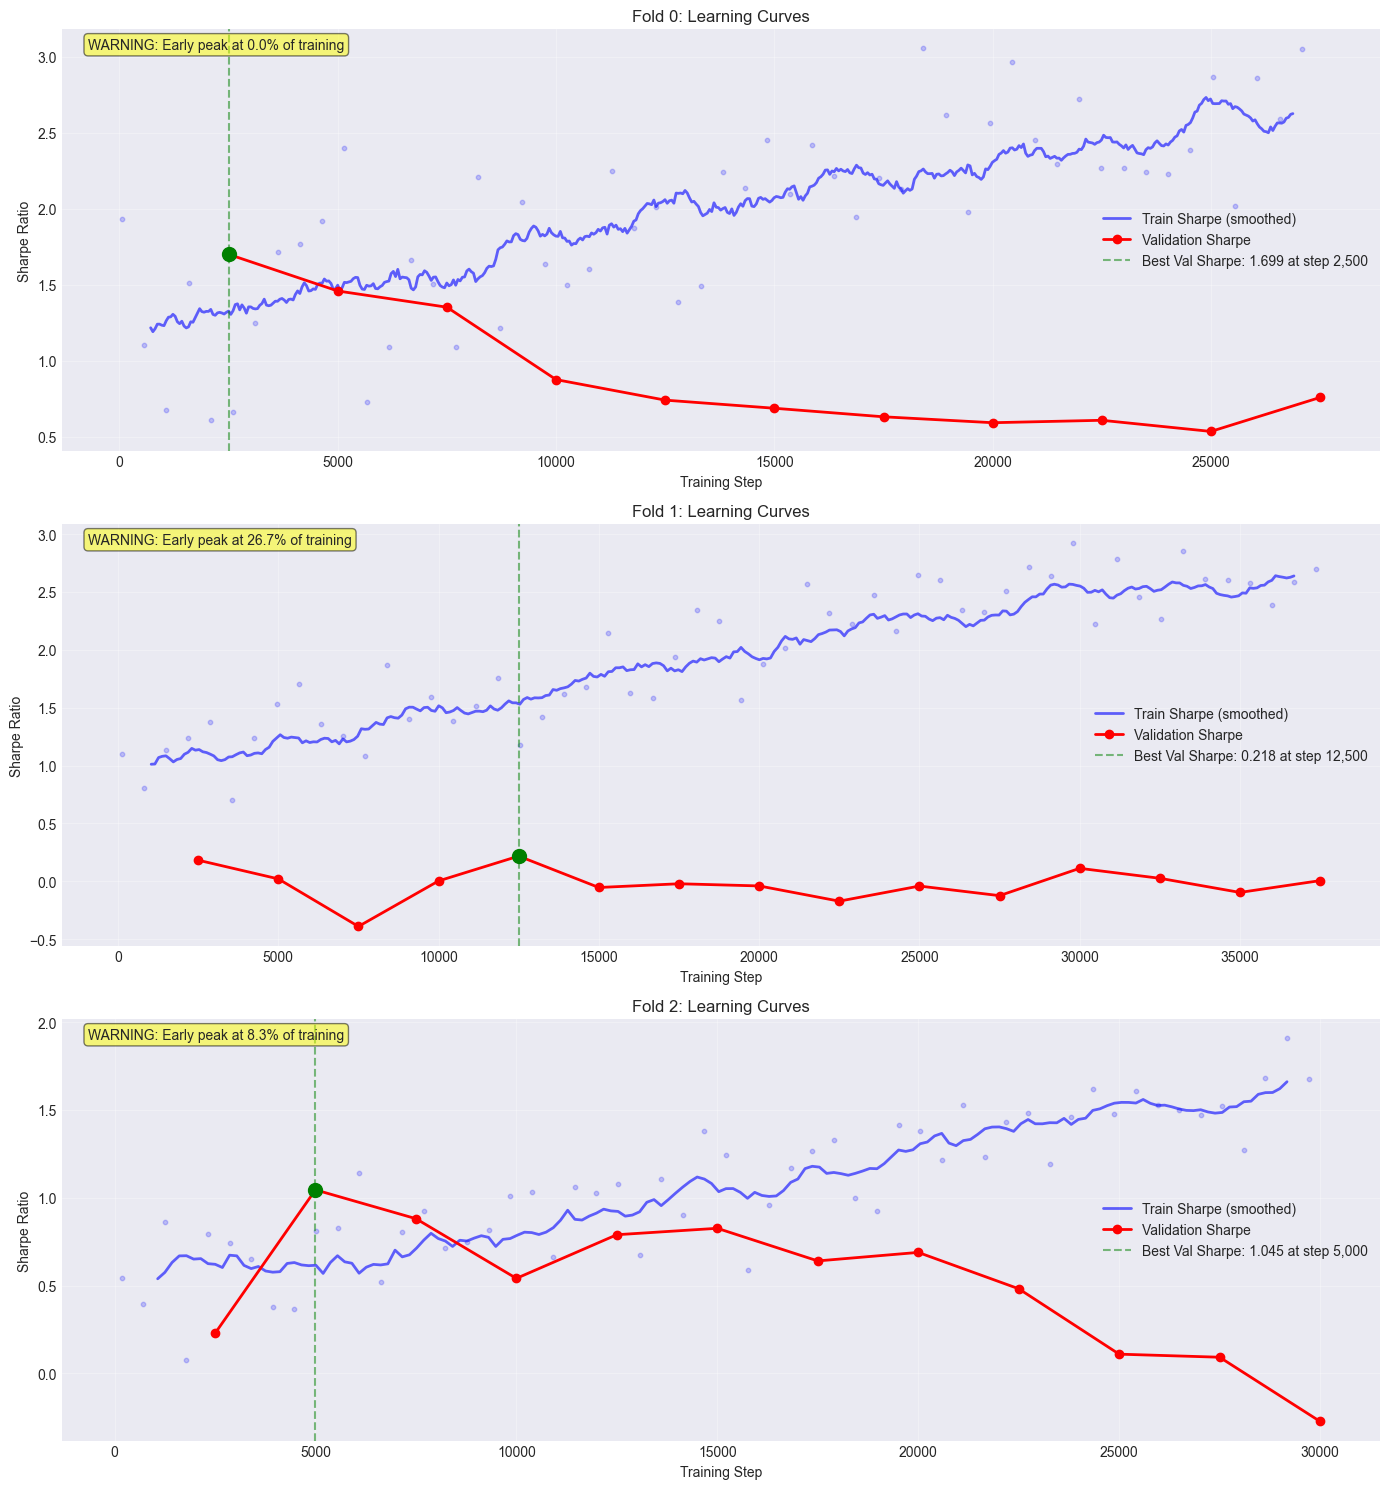

Learning curves saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/overfitting_analysis/ppo_risk_aware/learning_curves.png

2. Peak Position Analysis:
Validation Sharpe Peak Analysis:

Fold 0.0:
  Peak Sharpe: 1.699 at step 2,500.0
  Final Sharpe: 0.758
  Peak position: 0.0% of training
  Decline from peak: 0.941 (55.4%)

Fold 1.0:
  Peak Sharpe: 0.218 at step 12,500.0
  Final Sharpe: 0.006
  Peak position: 26.7% of training
  Decline from peak: 0.212 (97.1%)

Fold 2.0:
  Peak Sharpe: 1.045 at step 5,000.0
  Final Sharpe: -0.273
  Peak position: 8.3% of training
  Decline from peak: 1.318 (126.1%)


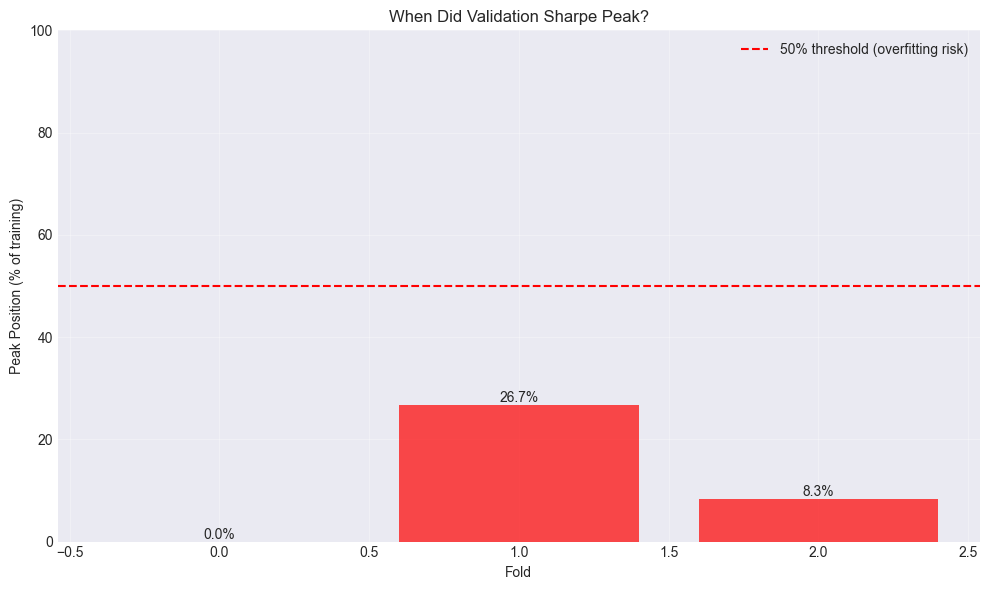


Peak analysis plot saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/overfitting_analysis/ppo_risk_aware/peak_analysis.png

3. Train vs Validation Comparison:


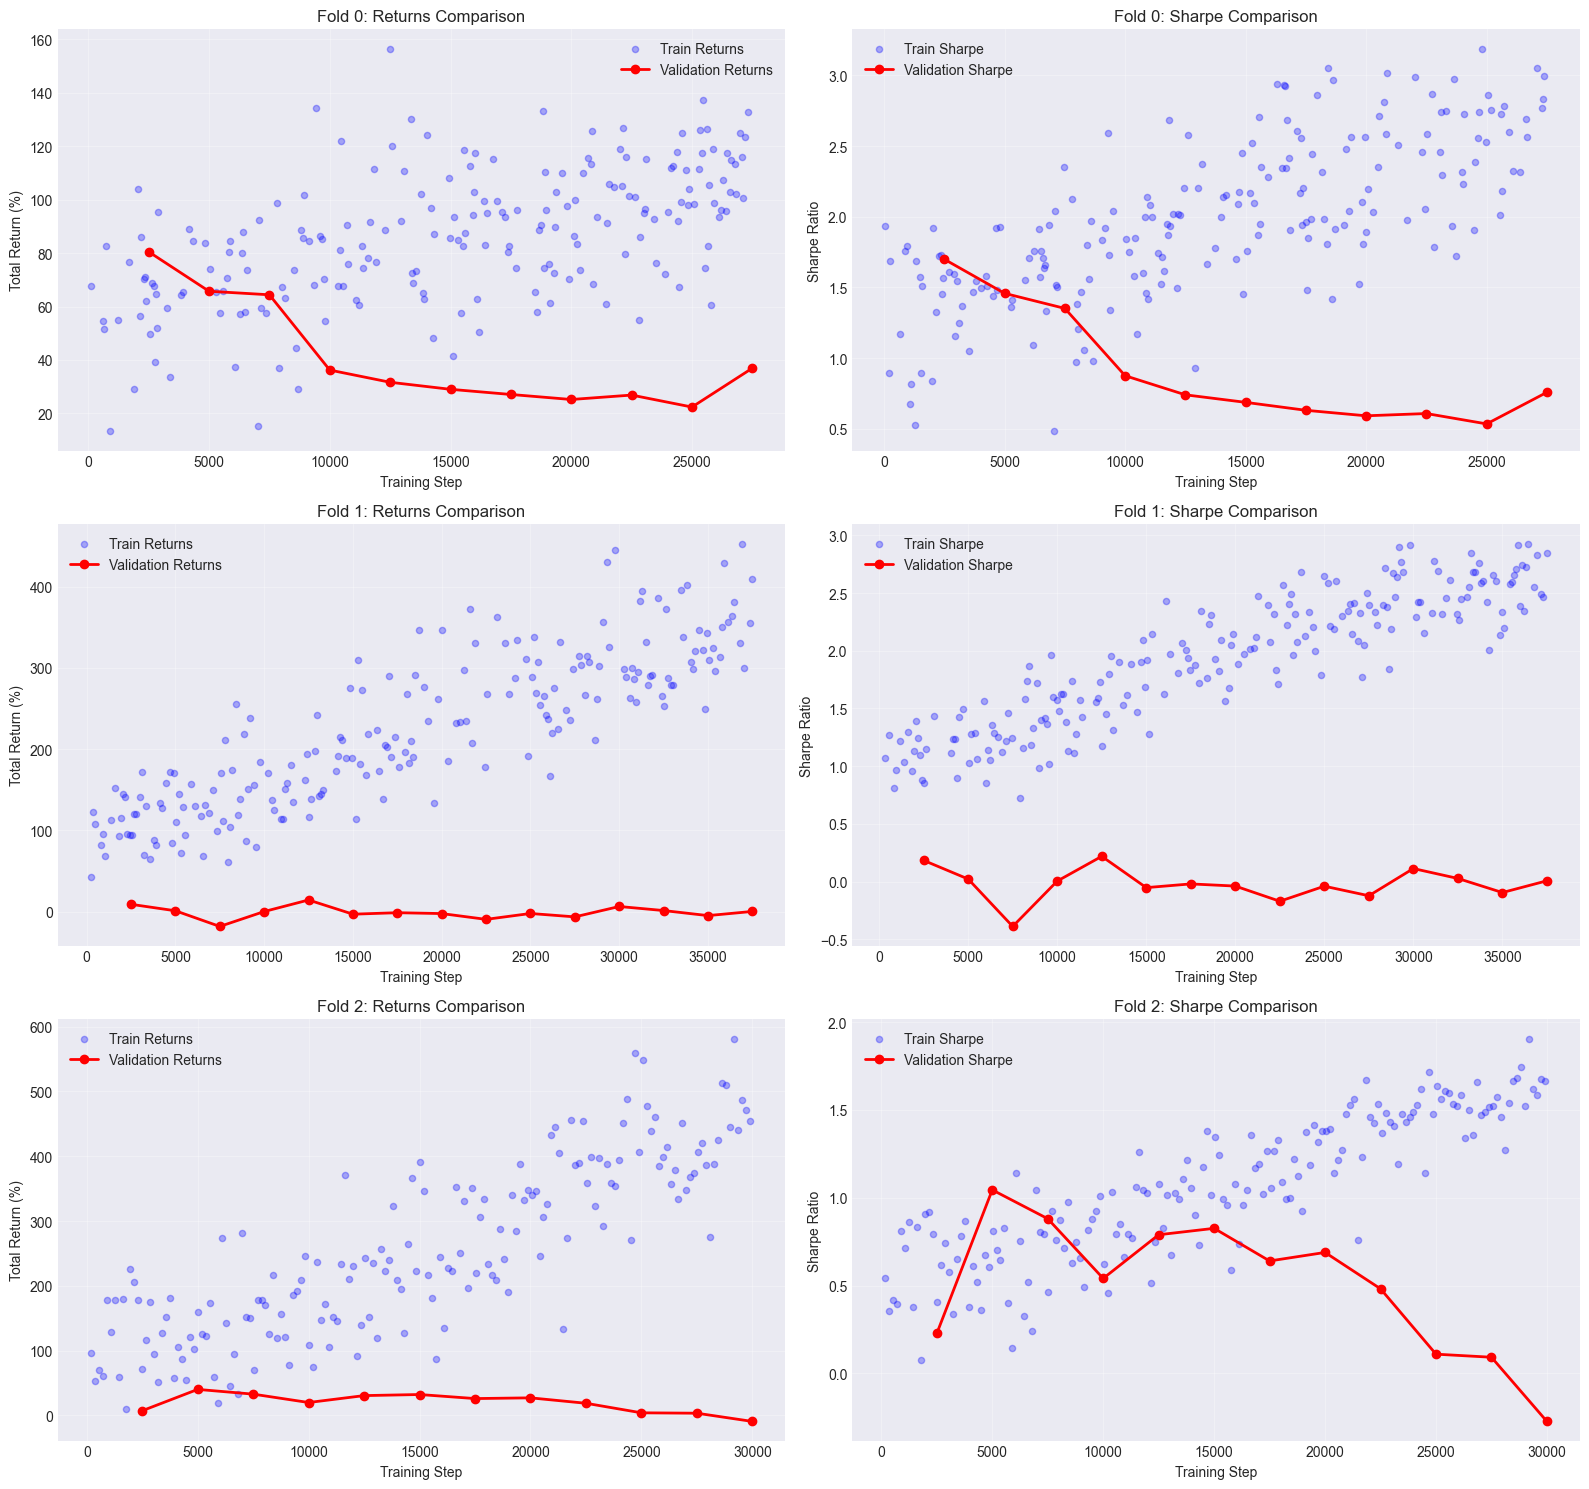


Train vs Validation Returns Summary:

Fold 0:
  Train Return: 82.61% ± 26.10%
  Val Return:   40.54% ± 19.95%
  Gap: 42.06%

Fold 1:
  Train Return: 227.49% ± 92.53%
  Val Return:   -0.97% ± 7.67%
  Gap: 228.47%

Fold 2:
  Train Return: 255.00% ± 134.21%
  Val Return:   19.33% ± 14.98%
  Gap: 235.67%

Train vs validation comparison plot saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/overfitting_analysis/ppo_risk_aware/train_val_comparison.png

✓ Individual analysis complete for risk_aware
✓ Results saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/overfitting_analysis/ppo_risk_aware


In [5]:
reward_type = 'risk_aware'
model_data = all_models_data[reward_type]

print(f"{'='*80}")
print(f"PPO - {reward_type.upper()} REWARD")
print(f"{'='*80}\n")

model_output_dir = OUTPUT_DIR / f"ppo_{reward_type}"
model_output_dir.mkdir(parents=True, exist_ok=True)

print("\n1. Learning Curves Analysis:")
plot_learning_curves(model_data['train'], model_data['val'], model_output_dir)

print("\n2. Peak Position Analysis:")
peak_df_risk = analyze_peak_positions(model_data['val'], model_output_dir)

print("\n3. Train vs Validation Comparison:")
plot_train_val_comparison(model_data['train'], model_data['val'], model_output_dir)

print(f"\n✓ Individual analysis complete for {reward_type}")
print(f"✓ Results saved to: {model_output_dir}")

### 1.4 Individual Model Overfitting Summary

In [6]:
print(f"\n{'='*80}")
print("INDIVIDUAL MODEL OVERFITTING ASSESSMENT")
print(f"{'='*80}\n")

models_peak_analysis = {
    'log_return': peak_df_log,
    'multi_component': peak_df_multi,
    'risk_aware': peak_df_risk
}

for reward_type, peak_df in models_peak_analysis.items():
    print(f"\n{reward_type.upper()}:")
    print("-" * 80)
    
    for _, row in peak_df.iterrows():
        fold = row['fold']
        peak_pos = row['peak_position']
        decline_pct = row['decline_pct']
        
        signals = []
        if peak_pos < 0.5:
            signals.append('Early Peak')
        if decline_pct > 20:
            signals.append('Large Decline')
        
        risk = 'HIGH' if len(signals) >= 2 else 'MEDIUM' if len(signals) == 1 else 'LOW'
        
        print(f"  Fold {fold}: {risk} risk")
        print(f"    Peak at {peak_pos*100:.1f}% of training")
        print(f"    Decline: {decline_pct:.1f}%")
        if signals:
            print(f"    Signals: {', '.join(signals)}")

print(f"\n{'='*80}")


INDIVIDUAL MODEL OVERFITTING ASSESSMENT


LOG_RETURN:
--------------------------------------------------------------------------------
  Fold 0.0: HIGH risk
    Peak at 21.4% of training
    Decline: 56.1%
    Signals: Early Peak, Large Decline
  Fold 1.0: HIGH risk
    Peak at 21.4% of training
    Decline: 96.2%
    Signals: Early Peak, Large Decline
  Fold 2.0: MEDIUM risk
    Peak at 55.0% of training
    Decline: 42.5%
    Signals: Large Decline

MULTI_COMPONENT:
--------------------------------------------------------------------------------
  Fold 0.0: HIGH risk
    Peak at 21.4% of training
    Decline: 52.3%
    Signals: Early Peak, Large Decline
  Fold 1.0: HIGH risk
    Peak at 8.3% of training
    Decline: 33.6%
    Signals: Early Peak, Large Decline
  Fold 2.0: HIGH risk
    Peak at 0.0% of training
    Decline: 72.9%
    Signals: Early Peak, Large Decline

RISK_AWARE:
--------------------------------------------------------------------------------
  Fold 0.0: HIGH risk
 

---
## Part 2: Multi-Model Comparison

Compare all PPO models side-by-side to identify which reward type generalizes best.

### 2.1 Learning Curves: All Models


Comparing learning curves across all models...



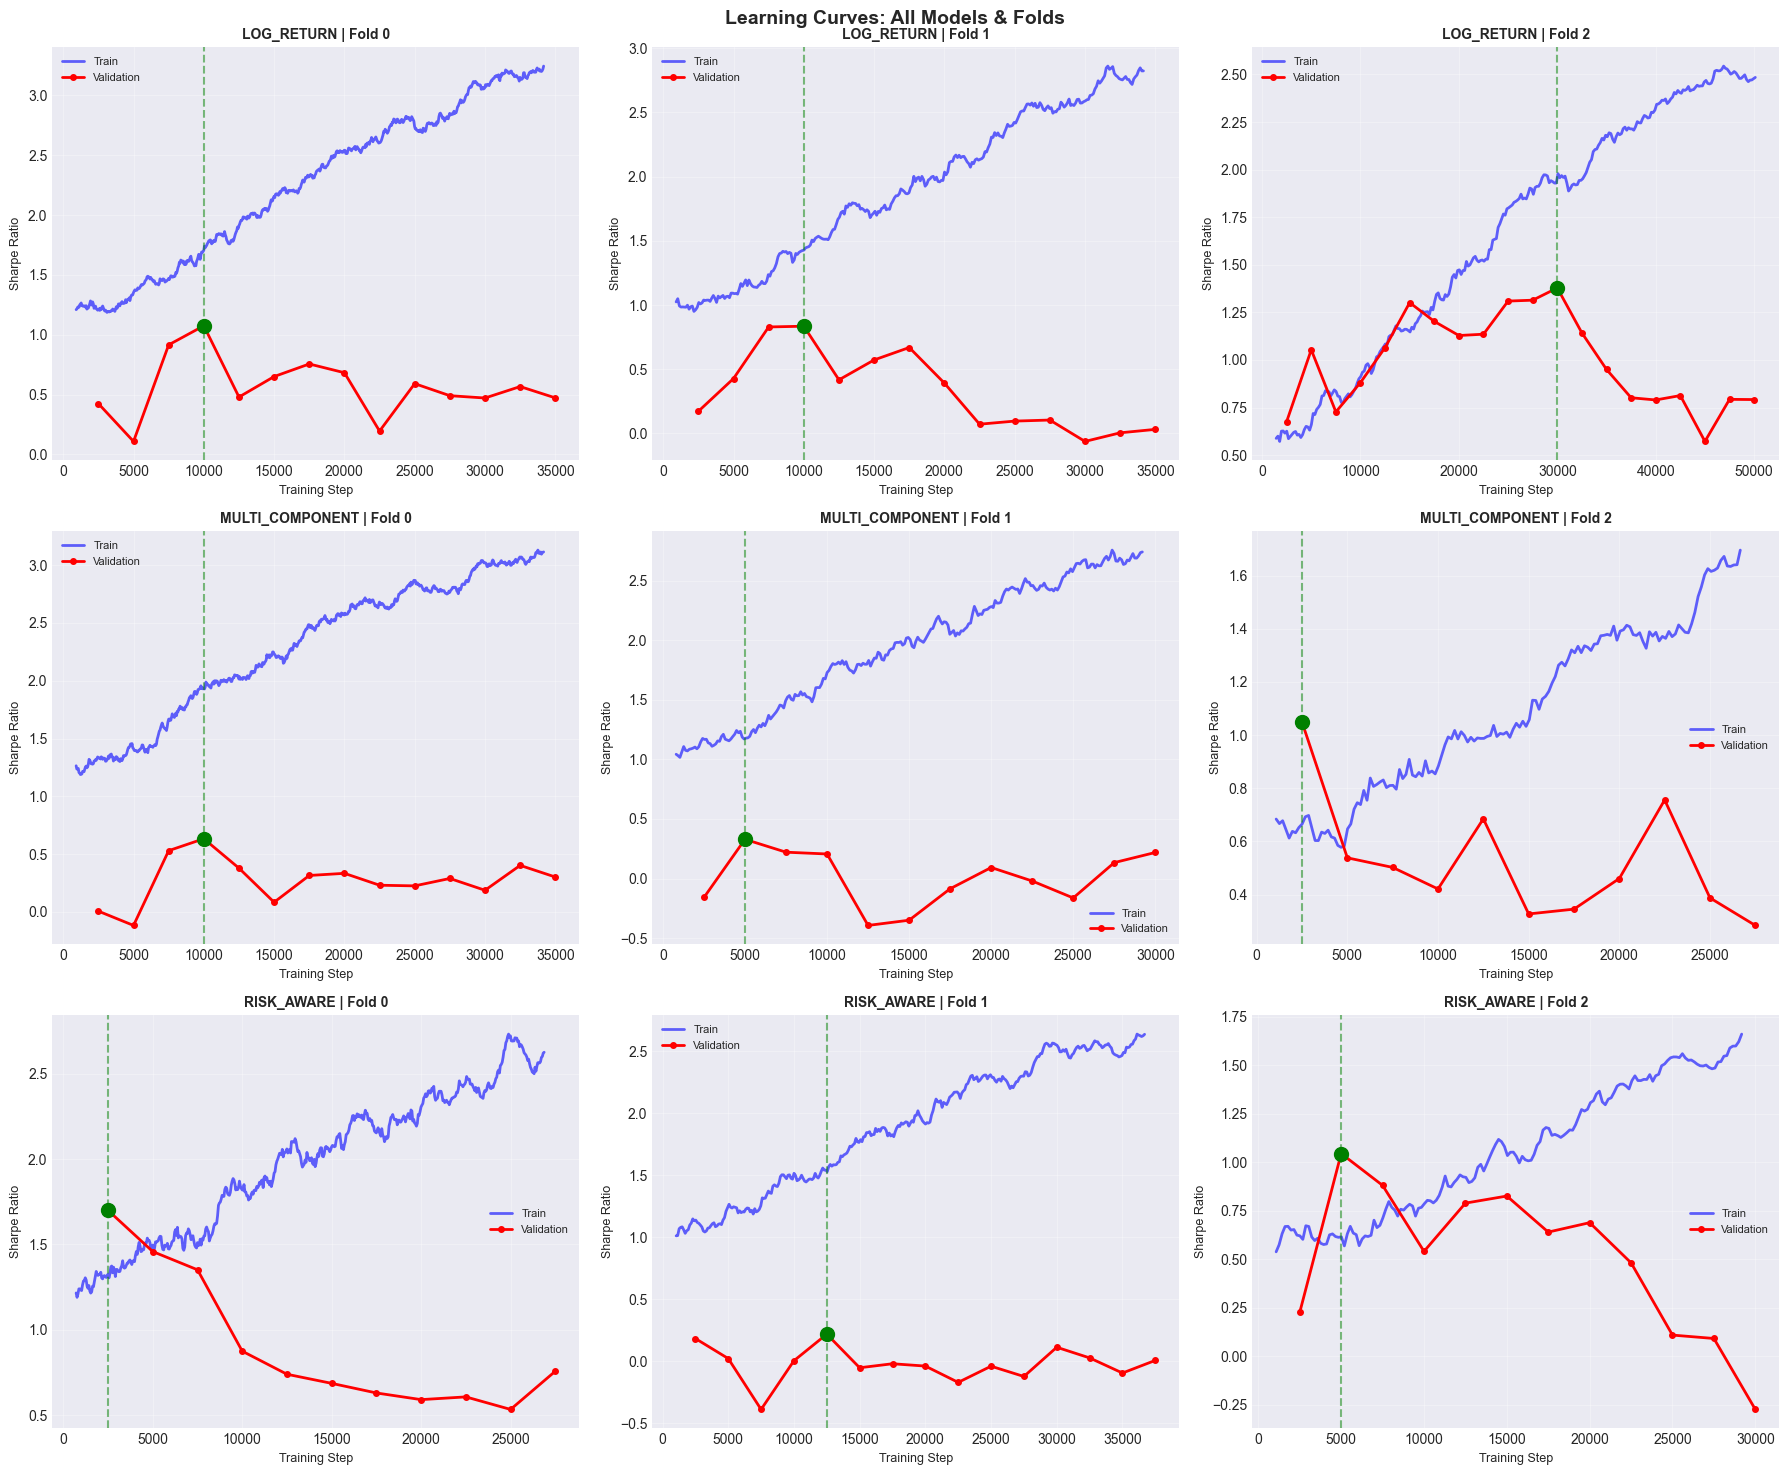

Multi-model learning curves saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/overfitting_analysis/multi_model_learning_curves.png

✓ Multi-model learning curves generated


In [7]:
print("\nComparing learning curves across all models...\n")

plot_multi_model_learning_curves(all_models_data, OUTPUT_DIR)

print("\n✓ Multi-model learning curves generated")

### 2.2 Overfitting Metrics Comparison


Comparing overfitting metrics...



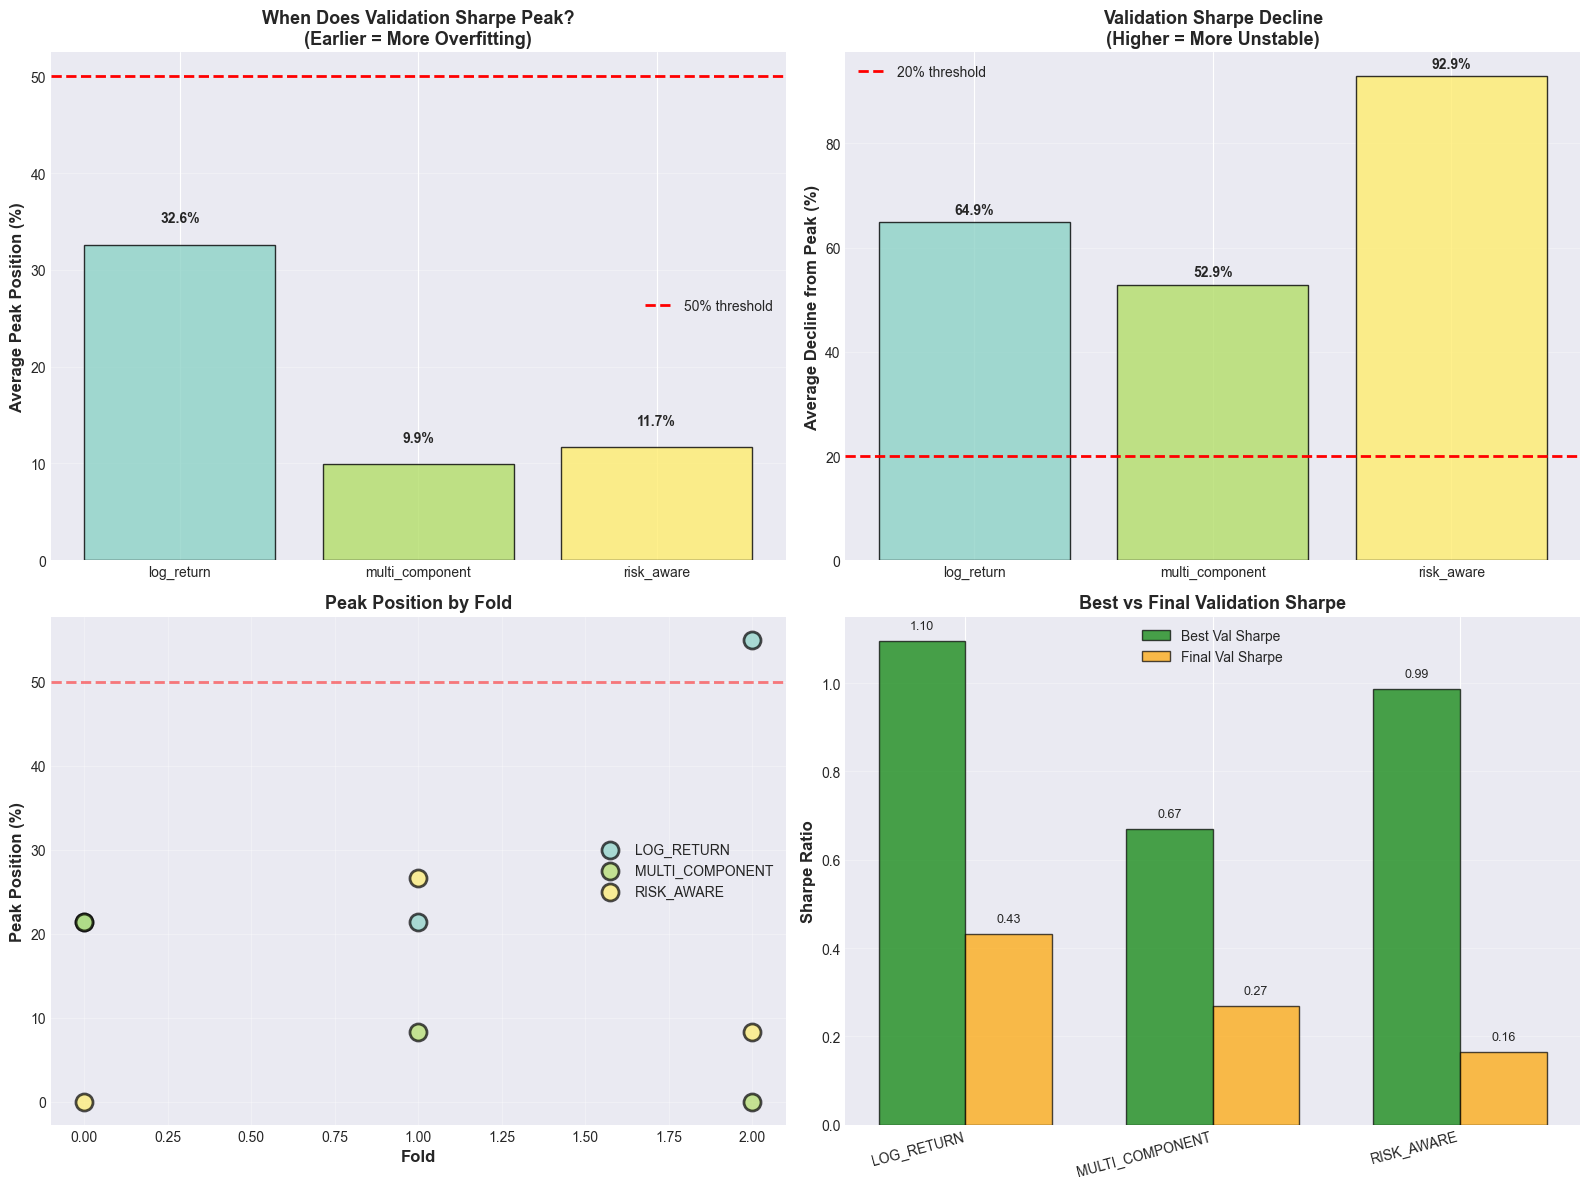

Overfitting metrics comparison saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/overfitting_analysis/overfitting_metrics_comparison.png

✓ Overfitting metrics comparison generated


In [8]:
print("\nComparing overfitting metrics...\n")

compare_overfitting_metrics(models_peak_analysis, OUTPUT_DIR)

print("\n✓ Overfitting metrics comparison generated")

### 2.3 Load Test Results for Validation-Test Gap Analysis

In [9]:
# Load backtest results
backtest_summary_path = RESULTS_DIR / 'backtest_summary_all_models.csv'

if backtest_summary_path.exists():
    backtest_df = pd.read_csv(backtest_summary_path)
    print(f"✓ Loaded backtest results from: {backtest_summary_path}\n")
    
    # Extract test Sharpe for each PPO model
    models_test_results = {}
    
    for reward_type in PPO_REWARD_TYPES:
        model_name = f"PPO_{reward_type}"
        
        # Find test results for this model
        model_row = backtest_df[backtest_df['Model'] == model_name]
        
        if len(model_row) > 0:
            test_sharpe = model_row['Test Sharpe'].values[0]
            
            # Load fold results (from training)
            model_dir = MODELS_DIR / f"ppo_{reward_type}"
            all_results_path = MODELS_DIR / 'ppo_all_rewards_results.csv'
            
            if all_results_path.exists():
                all_results = pd.read_csv(all_results_path)
                fold_results = all_results[all_results['reward_type'] == reward_type].copy()
                fold_results['fold_idx'] = fold_results['fold']
                fold_results['val_sharpe_ratio'] = fold_results['sharpe_ratio']
                fold_results['best_val_sharpe'] = fold_results['best_val_sharpe']
                
                # Use best fold (by best_val_sharpe)
                tested_fold = fold_results['best_val_sharpe'].idxmax()
                tested_fold_idx = fold_results.loc[tested_fold, 'fold']
                
                models_test_results[reward_type] = {
                    'fold_results': fold_results,
                    'test_sharpe': test_sharpe,
                    'tested_fold': tested_fold_idx
                }
                
                print(f"{reward_type}: Test Sharpe = {test_sharpe:.3f} (Fold {tested_fold_idx})")
    
    has_test_results = True
else:
    print(f"⚠️  Backtest results not found: {backtest_summary_path}")
    print("   Run the backtest notebook (03_backtests_all_models.ipynb) first.")
    has_test_results = False

✓ Loaded backtest results from: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/backtests/backtest_summary_all_models.csv

log_return: Test Sharpe = 0.755 (Fold 2)
multi_component: Test Sharpe = 0.916 (Fold 2)
risk_aware: Test Sharpe = 1.196 (Fold 0)


### 2.4 Validation-Test Gap Comparison


Comparing validation-test gaps...



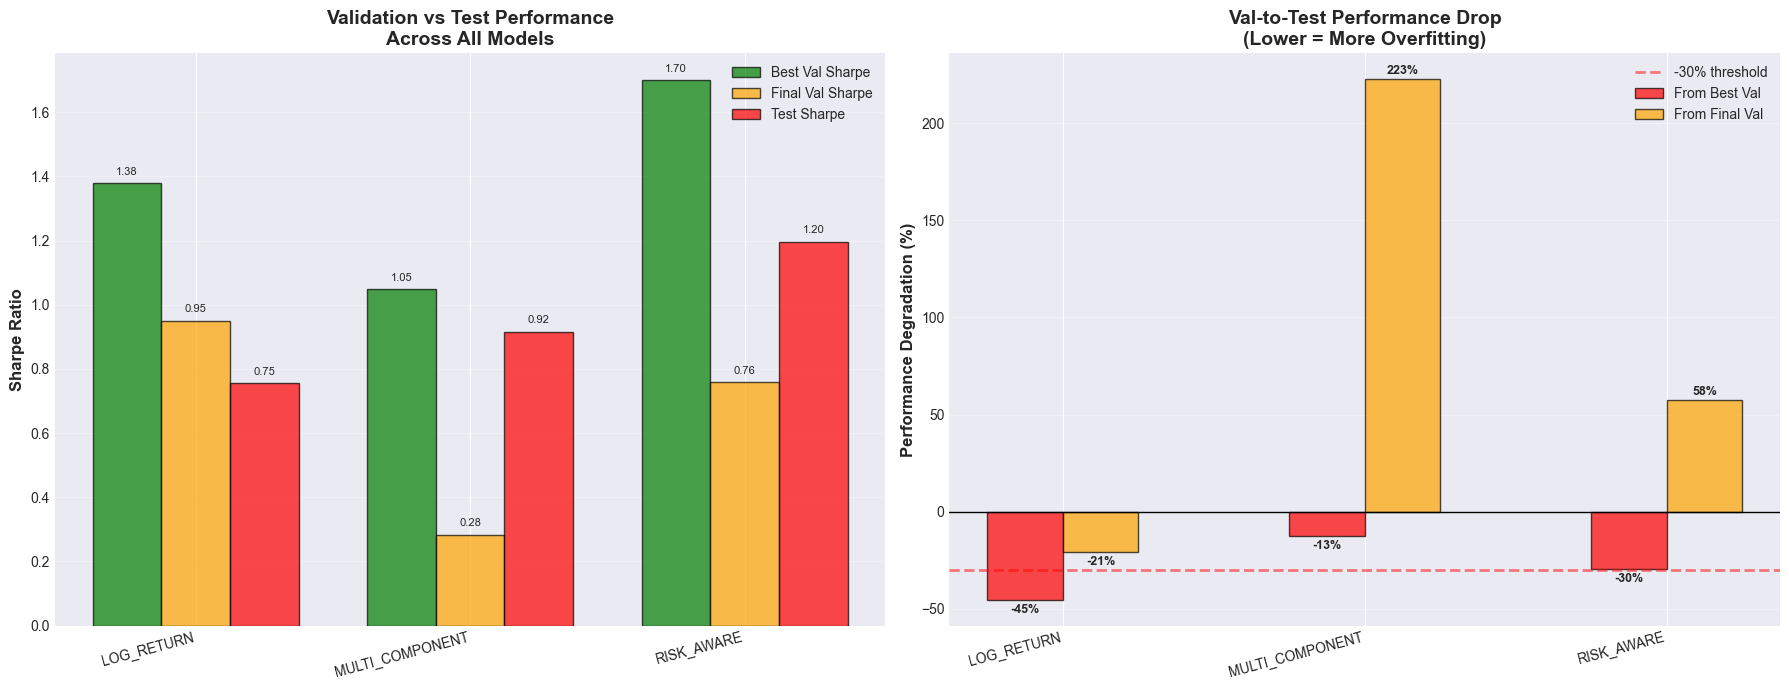

Multi-model val-test gap comparison saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/overfitting_analysis/multi_model_val_test_gap.png

✓ Validation-test gap comparison generated


In [10]:
if has_test_results and models_test_results:
    print("\nComparing validation-test gaps...\n")
    
    plot_multi_model_val_test_gap(models_test_results, OUTPUT_DIR)
    
    print("\n✓ Validation-test gap comparison generated")
else:
    print("\n⚠️  Skipping validation-test gap analysis (no test results available)")

### 2.5 Comprehensive Overfitting Summary Table

In [11]:
print("\nCreating comprehensive overfitting summary table...\n")

test_results_for_table = models_test_results if has_test_results else {}

summary_table = create_overfitting_summary_table(
    models_peak_analysis,
    test_results_for_table,
    OUTPUT_DIR
)

print("\n" + "="*100)
print("OVERFITTING SUMMARY TABLE")
print("="*100)
display(summary_table)
print("="*100)


Creating comprehensive overfitting summary table...


Overfitting summary table saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/overfitting_analysis/overfitting_summary_table.csv

OVERFITTING SUMMARY TABLE


,Model,Avg Peak Position,Avg Decline from Peak,Avg Best Val Sharpe,Avg Final Val Sharpe,Test Sharpe,Val-Test Gap,Risk Signals,Overfitting Risk
0,LOG_RETURN,32.6%,64.9%,1.096,0.432,0.755,-45%,"Early Peak, Large Decline, Val-Test Gap",HIGH
1,MULTI_COMPONENT,9.9%,52.9%,0.670,0.268,0.916,-13%,"Early Peak, Large Decline",HIGH
2,RISK_AWARE,11.7%,92.9%,0.988,0.164,1.196,-30%,"Early Peak, Large Decline",HIGH


---
## Part 3: Detailed Gap Analysis per Model

In [12]:
if has_test_results:
    print("\n" + "="*100)
    print("DETAILED VAL-TEST GAP ANALYSIS BY MODEL")
    print("="*100)
    
    for reward_type in sorted(models_test_results.keys()):
        data = models_test_results[reward_type]
        fold_results = data['fold_results']
        test_sharpe = data['test_sharpe']
        tested_fold = data['tested_fold']
        
        print(f"\n{'-'*100}")
        print(f"{reward_type.upper()} REWARD - FOLD {tested_fold}")
        print(f"{'-'*100}")
        
        fold_data = fold_results[fold_results['fold'] == tested_fold].iloc[0]
        best_sharpe = fold_data['best_val_sharpe']
        final_sharpe = fold_data['sharpe_ratio']
        
        print(f"\n1. VALIDATION PERFORMANCE:")
        print(f"   Best Sharpe (checkpoint): {best_sharpe:.3f}")
        print(f"   Final Sharpe (end): {final_sharpe:.3f}")
        
        decline = best_sharpe - final_sharpe
        decline_pct = (decline / best_sharpe * 100) if best_sharpe != 0 else 0
        print(f"   Decline during training: {decline:.3f} ({decline_pct:.1f}%)")
        
        print(f"\n2. TEST PERFORMANCE:")
        print(f"   Test Sharpe: {test_sharpe:.3f}")
        
        print(f"\n3. OVERFITTING GAPS:")
        gap_from_best = ((test_sharpe - best_sharpe) / best_sharpe * 100) if best_sharpe != 0 else 0
        gap_from_final = ((test_sharpe - final_sharpe) / final_sharpe * 100) if final_sharpe != 0 else 0
        
        print(f"   From Best Val to Test:  {best_sharpe:.3f} → {test_sharpe:.3f} = {gap_from_best:.1f}% {'drop' if gap_from_best < 0 else 'gain'}")
        print(f"   From Final Val to Test: {final_sharpe:.3f} → {test_sharpe:.3f} = {gap_from_final:.1f}% {'drop' if gap_from_final < 0 else 'gain'}")
        
        print(f"\n4. INTERPRETATION:")
        abs_gap = abs(gap_from_best)
        if abs_gap > 50:
            print(f"   🔴 SEVERE OVERFITTING ({gap_from_best:.0f}% drop)")
            print(f"      Model learned validation-specific patterns.")
        elif abs_gap > 30:
            print(f"   🟠 MODERATE OVERFITTING ({gap_from_best:.0f}% drop)")
            print(f"      Significant generalization gap.")
        elif abs_gap > 15:
            print(f"   🟡 MILD OVERFITTING ({gap_from_best:.0f}% drop)")
            print(f"      Some generalization issues.")
        else:
            print(f"   🟢 GOOD GENERALIZATION ({gap_from_best:.0f}% gap)")
            print(f"      Model generalizes well to unseen data.")
    
    print(f"\n{'='*100}")
else:
    print("\n⚠️  Skipping detailed gap analysis (no test results available)")


DETAILED VAL-TEST GAP ANALYSIS BY MODEL

----------------------------------------------------------------------------------------------------
LOG_RETURN REWARD - FOLD 2
----------------------------------------------------------------------------------------------------

1. VALIDATION PERFORMANCE:
   Best Sharpe (checkpoint): 1.379
   Final Sharpe (end): 0.950
   Decline during training: 0.428 (31.1%)

2. TEST PERFORMANCE:
   Test Sharpe: 0.755

3. OVERFITTING GAPS:
   From Best Val to Test:  1.379 → 0.755 = -45.2% drop
   From Final Val to Test: 0.950 → 0.755 = -20.6% drop

4. INTERPRETATION:
   🟠 MODERATE OVERFITTING (-45% drop)
      Significant generalization gap.

----------------------------------------------------------------------------------------------------
MULTI_COMPONENT REWARD - FOLD 2
----------------------------------------------------------------------------------------------------

1. VALIDATION PERFORMANCE:
   Best Sharpe (checkpoint): 1.049
   Final Sharpe (end): 0.

---
## Part 4: Recommendations & Conclusions

In [13]:
print("\n" + "="*100)
print("RECOMMENDATIONS & CONCLUSIONS")
print("="*100)

# Rank models by overfitting severity
ranking = []
for reward_type, peak_df in models_peak_analysis.items():
    avg_peak_pos = peak_df['peak_position'].mean()
    avg_decline = peak_df['decline_pct'].mean()
    
    # Calculate overfitting score (higher = more overfitting)
    # Early peak contributes 50%, large decline contributes 50%
    peak_score = max(0, (0.5 - avg_peak_pos)) * 200  # 0-100 scale
    decline_score = min(100, avg_decline)  # 0-100 scale
    overfitting_score = (peak_score + decline_score) / 2
    
    ranking.append({
        'reward_type': reward_type,
        'avg_peak_pos': avg_peak_pos,
        'avg_decline': avg_decline,
        'overfitting_score': overfitting_score
    })

ranking_df = pd.DataFrame(ranking).sort_values('overfitting_score')

print("\n🏆 REWARD TYPE RANKING (by generalization):")
print("-" * 100)
for rank, (_, row) in enumerate(ranking_df.iterrows(), 1):
    reward = row['reward_type']
    score = row['overfitting_score']
    
    if score < 30:
        status = "🟢 EXCELLENT"
    elif score < 50:
        status = "🟡 GOOD"
    elif score < 70:
        status = "🟠 FAIR"
    else:
        status = "🔴 POOR"
    
    print(f"  #{rank}. {reward.upper():20s} {status:20s} (score: {score:.1f})")
    print(f"      Peak position: {row['avg_peak_pos']*100:.1f}%, Avg decline: {row['avg_decline']:.1f}%")

best_reward = ranking_df.iloc[0]['reward_type']
worst_reward = ranking_df.iloc[-1]['reward_type']

print(f"\n💡 KEY FINDINGS:")
print(f"   • Best reward type: {best_reward.upper()}")
print(f"   • Worst reward type: {worst_reward.upper()}")

if has_test_results:
    # Find best test performance
    best_test_model = max(models_test_results.items(), key=lambda x: x[1]['test_sharpe'])
    best_test_reward = best_test_model[0]
    best_test_sharpe = best_test_model[1]['test_sharpe']
    
    print(f"   • Best test performance: {best_test_reward.upper()} (Sharpe: {best_test_sharpe:.3f})")
    
    if best_test_reward == best_reward:
        print(f"   ✅ Best generalization = best test performance!")
    else:
        print(f"   ⚠️  Best test ({best_test_reward}) ≠ best generalization ({best_reward})")

print(f"\n📋 RECOMMENDATIONS:")
print(f"   1. Production Model: Use {best_reward.upper()} reward (best generalization)")
if has_test_results and best_test_reward != best_reward:
    print(f"      Alternative: {best_test_reward.upper()} has best test Sharpe")
print(f"   2. Training: Reduce patience to stop earlier (before overfitting)")
print(f"   3. Ensemble: Consider averaging predictions from all 3 models")
print(f"   4. Improvement: Simplify {worst_reward.upper()} reward to reduce overfitting")

print(f"\n📊 SUMMARY:")
print(f"   • All models analyzed: {len(PPO_REWARD_TYPES)} PPO variants")
print(f"   • Folds per model: {N_FOLDS}")
print(f"   • Total training runs: {len(PPO_REWARD_TYPES) * N_FOLDS}")
print(f"   • Output directory: {OUTPUT_DIR}")

print(f"\n{'='*100}")
print("✅ OVERFITTING INVESTIGATION COMPLETE")
print(f"{'='*100}")


RECOMMENDATIONS & CONCLUSIONS

🏆 REWARD TYPE RANKING (by generalization):
----------------------------------------------------------------------------------------------------
  #1. LOG_RETURN           🟡 GOOD               (score: 49.9)
      Peak position: 32.6%, Avg decline: 64.9%
  #2. MULTI_COMPONENT      🟠 FAIR               (score: 66.5)
      Peak position: 9.9%, Avg decline: 52.9%
  #3. RISK_AWARE           🔴 POOR               (score: 84.8)
      Peak position: 11.7%, Avg decline: 92.9%

💡 KEY FINDINGS:
   • Best reward type: LOG_RETURN
   • Worst reward type: RISK_AWARE
   • Best test performance: RISK_AWARE (Sharpe: 1.196)
   ⚠️  Best test (risk_aware) ≠ best generalization (log_return)

📋 RECOMMENDATIONS:
   1. Production Model: Use LOG_RETURN reward (best generalization)
      Alternative: RISK_AWARE has best test Sharpe
   2. Training: Reduce patience to stop earlier (before overfitting)
   3. Ensemble: Consider averaging predictions from all 3 models
   4. Improvement: 

## Notes

**Analysis Performed:**
- Individual learning curves for each model
- Peak position analysis (early peaking = overfitting)
- Train-validation gap analysis
- Multi-model comparison
- Validation-test gap analysis (if test results available)

**Visualization Functions Used:**
- `plot_learning_curves` - Individual model analysis
- `analyze_peak_positions` - Peak detection
- `plot_train_val_comparison` - Train vs val gaps
- `plot_multi_model_learning_curves` - Cross-model comparison
- `compare_overfitting_metrics` - Overfitting metrics
- `plot_multi_model_val_test_gap` - Val-test gaps
- `create_overfitting_summary_table` - Summary table

**Output Files:**
- Individual model plots in `results/overfitting_analysis/ppo_{reward_type}/`
- Comparison plots in `results/overfitting_analysis/`
- Summary table: `overfitting_summary_table.csv`

**Interpretation Guide:**
- **Peak Position < 50%**: Model overfits early in training
- **Decline > 20%**: Unstable validation performance
- **Val-Test Gap > 30%**: Severe overfitting
- **Lower overfitting score**: Better generalization

**Next Steps:**
1. Choose best reward type based on analysis
2. Retrain with early stopping adjustments
3. Consider ensemble of top models
4. Monitor test performance for final validation